[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jen1995/jen1995.github.io/blob/main/notebooks/transformer_training.ipynb)

This notebook accompanies **Part 3** of the post [Transformers from Scratch](https://jen1995.github.io/posts/transformers/): the full model assembled from the blocks of Part 2, trained on the string-reversal task, plus greedy decoding and the KV-cache check. Runs on a CPU in a couple of minutes.

# Transformers from Scratch. Part 3 — Assembly, training, inference

The building blocks of Part 2 are ready and checked against the references. In this part we will assemble a full model out of them, train it on a toy task (for real, on a CPU, in a couple of minutes), learn to generate answers — and pay off the main debt of the series: count the complexity of the Transformer as a whole, including memory and inference.

## The blocks of Part 2 — now with batches

In Part 2 we worked with a single sequence for clarity: the input had shape $(n, d)$. For training we need to process a pack of examples at once, so all tensors gain a batch dimension: $(b, n, d)$. The good news: almost nothing needs to change — all the operations are written with `@` and work with any number of leading dimensions; only `split_heads` has changed.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
np.random.seed(0)

def scaled_dot_product_attention(q, k, v, mask=None):
    scores = q @ k.transpose(-2, -1) / q.shape[-1] ** 0.5
    if mask is not None:
        scores = scores.masked_fill(~mask, float("-inf"))
    weights = F.softmax(scores, dim=-1)
    return weights @ v, weights

class MultiHeadAttention(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        assert d % h == 0
        self.d, self.h, self.d_head = d, h, d // h
        self.w_q = nn.Linear(d, d, bias=False)
        self.w_k = nn.Linear(d, d, bias=False)
        self.w_v = nn.Linear(d, d, bias=False)
        self.w_o = nn.Linear(d, d, bias=False)

    def split_heads(self, x):                  # (b, n, d) -> (b, h, n, d/h)
        b, n, _ = x.shape
        return x.view(b, n, self.h, self.d_head).transpose(1, 2)

    def forward(self, x_q, x_k, x_v, mask=None):
        q = self.split_heads(self.w_q(x_q))
        k = self.split_heads(self.w_k(x_k))
        v = self.split_heads(self.w_v(x_v))
        out, _ = scaled_dot_product_attention(q, k, v, mask)
        b, _, n, _ = out.shape
        return self.w_o(out.transpose(1, 2).reshape(b, n, self.d))

class FeedForward(nn.Module):
    def __init__(self, d, d_ff):
        super().__init__()
        self.lin1 = nn.Linear(d, d_ff)
        self.lin2 = nn.Linear(d_ff, d)

    def forward(self, x):
        return self.lin2(F.relu(self.lin1(x)))

def positional_encoding(n, d):
    pos = torch.arange(n).unsqueeze(1)
    i = torch.arange(0, d, 2)
    angles = pos / 10000 ** (i / d)
    pe = torch.zeros(n, d)
    pe[:, 0::2] = torch.sin(angles)
    pe[:, 1::2] = torch.cos(angles)
    return pe

def causal_mask(n):
    return torch.tril(torch.ones(n, n, dtype=torch.bool))

A mask of shape $(n, n)$ is automatically broadcast over all batches and heads of the score tensor $(b, h, n, n)$ — another place where PyTorch's numpy conventions save code.

## The encoder layer

The recipe from the overview in Part 1: self-attention (tokens exchange information), then the FFN (each token digests what was gathered), and each of the two blocks is wrapped in a residual connection with LayerNorm.

In [2]:
class EncoderLayer(nn.Module):
    def __init__(self, d, h, d_ff):
        super().__init__()
        self.attn = MultiHeadAttention(d, h)
        self.ffn = FeedForward(d, d_ff)
        self.norm1 = nn.LayerNorm(d)
        self.norm2 = nn.LayerNorm(d)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.attn(x, x, x, mask))
        x = self.norm2(x + self.ffn(x))
        return x

Let us check the whole layer against a numpy reference assembled from the verified parts of Part 2 (repeated here once more, unchanged):

In [3]:
def softmax_np(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

def attention_np(q, k, v, mask=None):
    scores = q @ np.swapaxes(k, -2, -1) / np.sqrt(q.shape[-1])
    if mask is not None:
        scores = np.where(mask, scores, -np.inf)
    weights = softmax_np(scores)
    return weights @ v, weights

def multi_head_attention_np(x, w_q, w_k, w_v, w_o, h):
    n, d = x.shape
    d_head = d // h

    def split(m):
        return m.reshape(n, h, d_head).transpose(1, 0, 2)

    q, k, v = split(x @ w_q), split(x @ w_k), split(x @ w_v)
    out, _ = attention_np(q, k, v)
    concat = out.transpose(1, 0, 2).reshape(n, d)
    return concat @ w_o

def feed_forward_np(x, w1, b1, w2, b2):
    return np.maximum(x @ w1 + b1, 0.0) @ w2 + b2

def add_norm_np(x, block_out, gamma, beta, eps=1e-5):
    z = x + block_out
    mu = z.mean(axis=-1, keepdims=True)
    var = z.var(axis=-1, keepdims=True)
    return gamma * (z - mu) / np.sqrt(var + eps) + beta

def encoder_layer_np(x, layer, h):
    p = lambda t: t.detach().numpy()
    a = layer.attn
    attn = multi_head_attention_np(x, p(a.w_q.weight).T, p(a.w_k.weight).T,
                                   p(a.w_v.weight).T, p(a.w_o.weight).T, h)
    x = add_norm_np(x, attn, p(layer.norm1.weight), p(layer.norm1.bias))
    ffn = feed_forward_np(x, p(layer.ffn.lin1.weight).T, p(layer.ffn.lin1.bias),
                          p(layer.ffn.lin2.weight).T, p(layer.ffn.lin2.bias))
    return add_norm_np(x, ffn, p(layer.norm2.weight), p(layer.norm2.bias))

d, h, d_ff, n = 64, 4, 256, 10
layer = EncoderLayer(d, h, d_ff)
x = torch.randn(1, n, d)

assert np.allclose(layer(x).detach().numpy()[0],
                   encoder_layer_np(x[0].numpy(), layer, h), atol=1e-5)
print("encoder layer: ok")

encoder layer: ok


**Layer complexity.** Attention $O(n^2 \cdot d + n \cdot d^2)$ + FFN $O(n \cdot d \cdot d_{ff})$ + Add & Norm $O(n \cdot d)$. At the standard $d_{ff} = 4d$ the whole thing remains $O(n^2 \cdot d + n \cdot d^2)$ — the attention formula absorbs the rest.

## The decoder layer

The decoder layer has three blocks, and all three are familiar:

1. **masked self-attention** — the target-sequence tokens look at their own prefix (the causal mask from Part 2);
2. **cross-attention** — the heir of Bahdanau's attention from Part 0: queries from the decoder, keys and values from the encoder. The same `MultiHeadAttention` class, just different inputs;
3. **FFN** — unchanged.

In [4]:
class DecoderLayer(nn.Module):
    def __init__(self, d, h, d_ff):
        super().__init__()
        self.self_attn = MultiHeadAttention(d, h)
        self.cross_attn = MultiHeadAttention(d, h)
        self.ffn = FeedForward(d, d_ff)
        self.norm1 = nn.LayerNorm(d)
        self.norm2 = nn.LayerNorm(d)
        self.norm3 = nn.LayerNorm(d)

    def forward(self, y, enc_out, mask):
        y = self.norm1(y + self.self_attn(y, y, y, mask))
        y = self.norm2(y + self.cross_attn(y, enc_out, enc_out))
        y = self.norm3(y + self.ffn(y))
        return y

The cross-check is organized just like for the encoder — all the parts have already been verified, so we omit the reference code. The complexity is the same up to a constant: cross-attention adds another $O(n^2 \cdot d + n \cdot d^2)$ (more precisely $O(n_{tgt} \cdot n_{src} \cdot d + \dots)$ — the score table is now "target × source").

## The full model

We assemble everything according to the scheme from Part 1 — here it is again as a reminder:

Embeddings (multiplied by $\sqrt{d}$ — that debt from Part 2) + positional encoding, a stack of encoder layers, a stack of decoder layers, an output projection into the vocabulary size — we now have code for every element of the scheme.

In [5]:
class Transformer(nn.Module):
    def __init__(self, vocab_size, d, h, d_ff, n_layers, max_len=512):
        super().__init__()
        self.d = d
        self.emb_src = nn.Embedding(vocab_size, d)
        self.emb_tgt = nn.Embedding(vocab_size, d)
        self.register_buffer("pe", positional_encoding(max_len, d))
        self.enc_layers = nn.ModuleList(EncoderLayer(d, h, d_ff) for _ in range(n_layers))
        self.dec_layers = nn.ModuleList(DecoderLayer(d, h, d_ff) for _ in range(n_layers))
        self.out_proj = nn.Linear(d, vocab_size)

    def encode(self, src):
        x = self.emb_src(src) * self.d ** 0.5 + self.pe[: src.shape[1]]
        for layer in self.enc_layers:
            x = layer(x)
        return x

    def decode(self, tgt, enc_out):
        mask = causal_mask(tgt.shape[1])
        y = self.emb_tgt(tgt) * self.d ** 0.5 + self.pe[: tgt.shape[1]]
        for layer in self.dec_layers:
            y = layer(y, enc_out, mask)
        return self.out_proj(y)

    def forward(self, src, tgt):
        return self.decode(tgt, self.encode(src))

**The output layer** deserves a separate look at its complexity: the projection $(n \times d) \cdot (d \times |V|)$ costs $O(n \cdot d \cdot |V|)$. This is an often underestimated expense item. A quick estimate for machine translation: $|V| = 32{,}000$, $d = 512$. The output projection is $d \cdot |V| \approx 16.4$ million multiplications per token. And one layer (attention + FFN with $d_{ff} = 4d$) is roughly $10 d^2 + 2nd \approx 2.7$ million per token at $n = 50$; six layers — about 16 million. That is, the output projection costs roughly as much as **all six encoder layers put together**.

## How many parameters?

Let us count by the formulas and check against the fact:

- embeddings: $2 \lvert V \rvert d$ (source and target);
- an encoder layer: $4d^2$ (MHA) + $2 d \cdot d_{ff} + d_{ff} + d$ (FFN with bias) + $2 \cdot 2d$ (two LayerNorms);
- a decoder layer: $8d^2$ (two MHAs) + FFN + $3 \cdot 2d$;
- the output projection: $d\lvert V \rvert + \lvert V \rvert$.

In [6]:
vocab_size, n_layers = 11, 2
model = Transformer(vocab_size, d, h, d_ff, n_layers)

ffn_p = 2 * d * d_ff + d_ff + d
enc_p = 4 * d * d + ffn_p + 2 * 2 * d
dec_p = 8 * d * d + ffn_p + 3 * 2 * d
formula = 2 * vocab_size * d + n_layers * (enc_p + dec_p) + d * vocab_size + vocab_size

fact = sum(p.numel() for p in model.parameters())
assert formula == fact
print(f"parameters: {fact:,}")

parameters: 234,059


Note: positional encoding is absent from the list — it is not trained (we put it into `register_buffer`, not into `nn.Parameter`).

## Training: string reversal

To check whether our assembly "comes alive", we do not need a big dataset. Let us take a task that has everything a seq2seq model needs — an input, an output, a dependency of every output token on the input — but trains in minutes on a CPU: **reversing a sequence of symbols**. Input "3 7 1 5" → output "5 1 7 3". We reserve token 0 for `<bos>` (begin of sequence — the decoder starts generation from it).

In [7]:
seq_len, n_symbols = 10, 10   # vocabulary: 0 = <bos>, 1..10 — "letters"

def make_batch(batch_size):
    src = torch.randint(1, n_symbols + 1, (batch_size, seq_len))
    tgt = src.flip(1)
    bos = torch.zeros(batch_size, 1, dtype=torch.long)
    dec_in = torch.cat([bos, tgt[:, :-1]], dim=1)   # decoder input shifted by 1
    return src, dec_in, tgt

The main idea of the training is visible right here in the code — **teacher forcing**. The decoder learns to predict the $t$-th token from a prefix of the *correct* tokens $y_{\lt t}$ (not from its own past predictions): we feed the target shifted one position to the right (with `<bos>` at the front) as input, and require the unshifted target as the prediction. Thanks to the causal mask, all positions are trained simultaneously, in one pass — that very parallelization over the sequence for which the whole thing was started in Part 1.

The loss function is the cross-entropy from Part 0, applied at every position:

In [8]:
model = Transformer(vocab_size=n_symbols + 1, d=64, h=4, d_ff=256, n_layers=2)
opt = torch.optim.Adam(model.parameters(), lr=5e-4)

losses = []
for step in range(2000):
    src, dec_in, tgt = make_batch(128)
    logits = model(src, dec_in)                       # (b, n, |V|)
    loss = F.cross_entropy(logits.reshape(-1, logits.shape[-1]), tgt.reshape(-1))
    opt.zero_grad()
    loss.backward()
    opt.step()
    losses.append(loss.item())

print(f"loss: {losses[0]:.3f} → {losses[-1]:.4f}")

loss: 2.529 → 0.0060


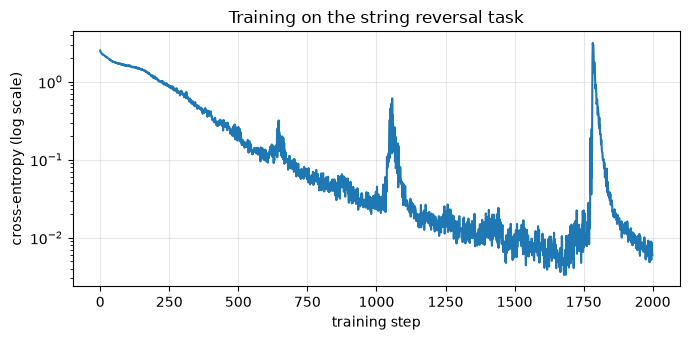

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 3.5))
plt.semilogy(losses)
plt.xlabel("training step")
plt.ylabel("cross-entropy (log scale)")
plt.title("Training on the string reversal task")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The rare spikes on the curve are not a bug: with Adam on small models, occasional gradient outliers happen, after which the loss returns to its trajectory within dozens of steps. In large models such spikes are fought with learning-rate warmup and gradient clipping; for our toy task it is enough that training recovers on its own.

In the original paper, **label smoothing** is added to the cross-entropy (the one-hot target distribution is slightly smeared over the vocabulary, $\varepsilon = 0.1$) — a regularization useful on real data; our task does not need it.

## Inference: generation token by token

The trained model predicts the next token — but how do we get a whole sequence? The same way the language model generated in Part 0: one token at a time. We start with `<bos>`, predict the first token, append it to the decoder input, predict the second — and so on. The simplest strategy is **greedy decoding**: at every step take the most probable token.

In [10]:
@torch.no_grad()
def greedy_decode(model, src, out_len):
    enc_out = model.encode(src)                       # encode the source once
    ys = torch.zeros(src.shape[0], 1, dtype=torch.long)   # <bos>
    for _ in range(out_len):
        logits = model.decode(ys, enc_out)
        next_tok = logits[:, -1].argmax(-1, keepdim=True)
        ys = torch.cat([ys, next_tok], dim=1)
    return ys[:, 1:]

src, _, tgt = make_batch(1000)
pred = greedy_decode(model, src, seq_len)
exact = (pred == tgt).all(dim=1).float().mean()
print(f"accuracy (exact match): {exact:.1%}")

accuracy (exact match): 99.5%


```text
accuracy (exact match): 99.5%
```

Let us look at the predictions with our own eyes. Numeric tokens are a convention; let us display symbols 1–10 as latin letters a–j, so the reversal is literally visible:

In [11]:
def to_str(tokens):
    return "".join(chr(ord("a") + t - 1) for t in tokens.tolist())

for i in range(5):
    ok = "✓" if (pred[i] == tgt[i]).all() else "✗"
    print(f"{to_str(src[i])} → {to_str(pred[i])}  {ok}")

wrong = (pred != tgt).any(dim=1).nonzero().flatten()
if len(wrong) > 0:
    i = wrong[0]
    print(f"\nerror example: {to_str(src[i])} → {to_str(pred[i])}")
    print(f"correct:       {' ' * (seq_len + 3)}{to_str(tgt[i])}")

gjcfhghhfg → gfhhghfcjg  ✓
hgfcacbgah → hagbcacfgh  ✓
gehbahfgja → ajgfhabheg  ✓
ieidhjgfag → gafgjhdiei  ✓
jjbbifcije → ejicfibbjj  ✓

error example: bhchhicehh → hhecihhcbh
correct:                    hhecihhchb


```text
gjcfhghhfg → gfhhghfcjg  ✓
hgfcacbgah → hagbcacfgh  ✓
gehbahfgja → ajgfhabheg  ✓
ieidhjgfag → gafgjhdiei  ✓
jjbbifcije → ejicfibbjj  ✓

error example: bhchhicehh → hhecihhcbh
correct:                    hhecihhchb
```

The character of the rare errors is telling in itself: they happen on strings with many repeats of the same symbol (five "h"s in the example above). This is no coincidence: identical tokens have identical embeddings, and attention can distinguish them only by the positional component — that very positional encoding from Part 2. Copying in reverse order is, at its core, pure positional work, and it is what fails first.

Greedy is not the only strategy. A greedy choice is irreversible: one mistake at the beginning ruins the whole tail, even if the model "knew" a better option. **Beam search** softens this: at every step not one but $k$ best prefixes are kept (by total log-likelihood), and the final answer is chosen among $k$ complete hypotheses. In translation, typical $k = 4\text{–}8$ give a noticeable quality boost; for our toy task, where the model is confident in every token, greedy is enough.

## Memory at training time: the hidden cost of quadraticity

We have been counting FLOPs all series long, but training has a second currency — **memory**. For the backward pass we must store the activations of all intermediate layers: gradients are computed by the chain rule from the output back to the input, and every layer needs its forward-pass inputs for that.

The hungriest activation is the attention weight table: $n \times n$ for **every head of every layer**. A quick estimate for a modest-by-today's-standards config:

In [12]:
n, h_, N_ = 4096, 8, 12       # context length, heads, layers
attn_bytes = N_ * h_ * n * n * 4        # float32
print(f"attention matrices: {attn_bytes / 2**30:.1f} GiB per example")

attention matrices: 6.0 GiB per example


```text
attention matrices: 6.0 GiB per example
```

Six gigabytes — just for the attention tables, just for one example in the batch, and we have not yet counted the FFN activations or the gradients with the optimizer state. The FLOPs, meanwhile, are perfectly manageable — it is memory we hit first: it grows as $O(N \cdot h \cdot n^2)$, and doubling the context length quadruples the bill. That is why long context has historically been a memory problem, not an arithmetic one.

> 💡 Modern attention implementations (e.g. FlashAttention) do not materialize the $n \times n$ table in full: the scores are computed in blocks and immediately folded into the output, and on the backward pass the missing parts are recomputed. The quadraticity of FLOPs stays; the quadraticity of memory goes away. This is beyond our series, but it is useful to know that "quadratic memory" is not a verdict.

## KV-cache: do not recompute the past

Let us look closely at our `greedy_decode`. At step $t$ we call `model.decode` on the **entire** prefix of $t$ tokens: we recompute Q, K, V for tokens that have not changed, and rebuild the $t \times t$ attention table. The cost of step $t$ is $O(t^2 \cdot d)$, and of the whole generation of $T$ tokens — $O(T^3 \cdot d)$. Wasteful: from step to step, exactly one token in the prefix changes.

The key observation: for its attention, the new token needs its own query $q_t$ — and the keys and values of **all the previous** tokens, which we already computed at past steps. So they can be cached: we store the accumulated $K$ and $V$ (a pair per layer), at each step compute the projections only for the one new token and append them to the cache. That is the **KV-cache**. The cost of step $t$ drops to $O(t \cdot d)$: one query against $t$ keys. The whole generation of $T$ tokens gets cheaper from $\sum_t O(t^2 d) = O(T^3 \cdot d)$ to $\sum_t O(t \cdot d) = O(T^2 \cdot d)$ — an order of $T$ better; the quadraticity remains (the last token still looks at all its predecessors), but the cubic wastefulness is gone.

Let us verify, at the level of a single attention layer, that incremental generation with a cache gives exactly the same result as full recomputation with a causal mask:

In [13]:
mha = MultiHeadAttention(d, h)
x = torch.randn(1, 20, d)

with torch.no_grad():
    full = mha(x, x, x, causal_mask(20))          # full recomputation

    k_cache, v_cache, outs = None, None, []
    for t in range(x.shape[1]):
        x_t = x[:, t : t + 1]                     # only the new token
        q = mha.split_heads(mha.w_q(x_t))
        k_new = mha.split_heads(mha.w_k(x_t))
        v_new = mha.split_heads(mha.w_v(x_t))
        k_cache = k_new if k_cache is None else torch.cat([k_cache, k_new], dim=2)
        v_cache = v_new if v_cache is None else torch.cat([v_cache, v_new], dim=2)
        out, _ = scaled_dot_product_attention(q, k_cache, v_cache)
        outs.append(mha.w_o(out.transpose(1, 2).reshape(1, 1, mha.d)))
    incremental = torch.cat(outs, dim=1)

assert torch.allclose(full, incremental, atol=1e-5)
print("KV-cache: matches full recomputation")

KV-cache: matches full recomputation


Notice: the causal mask was not needed in the incremental variant. The cache **is** the past — the new token physically cannot look into the future, because the future keys do not exist yet. The mask is only needed during training, when all positions are computed simultaneously.

We pay for the speedup with memory: the cache holds $2 \cdot N \cdot t \cdot d$ numbers and grows linearly with the generation length — in long dialogues with large models it is precisely the KV-cache that occupies a notable share of GPU memory. This trade — recomputation for storage — is an engineering classic, and in Part 2 we already saw its mirror image: FlashAttention trades storage for recomputation.